In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(RColorBrewer)
library(data.table)
library(ggplot2)
library(ggsci)
library(scales)
library(cowplot)

In [2]:
devtools::load_all("utils/modules/R/phasingtools/")

i Loading phasingtools

Loading required package: Hmisc

Loading required package: lattice

Loading required package: survival

Loading required package: Formula


Attaching package: 'Hmisc'


The following objects are masked from 'package:base':

    format.pval, units


Loading required package: stringr

! Skipping missing files: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_site.R

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_pos.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/bp_betwen_single_switches.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/eval_gt_agreement_by_bin.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasi

In [3]:
x <- readLines("data/phased/wes_union_calls/200k/shapeit5/switch_pp90/gt_singleton.txt")

In [25]:
d <- fread("data/permute/permutations/chr1/ENSG00000042781/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr1_ENSG00000042781_spiro_visual_impairment_and_blindness.pvalues.txt.gz")

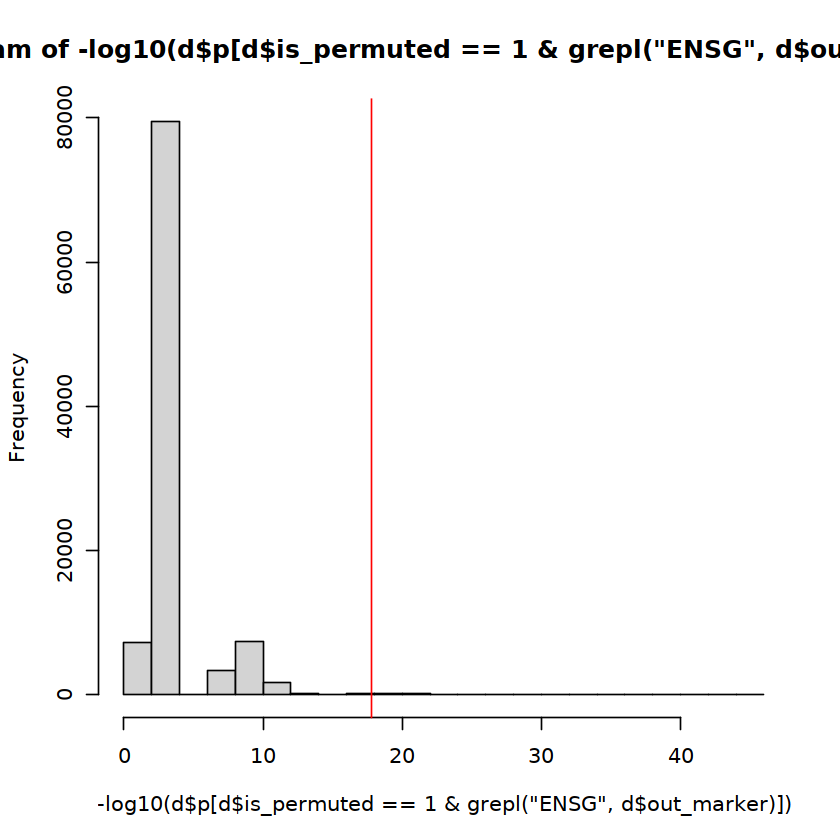

In [26]:
hist(-log10(d$p[d$is_permuted == 1 & grepl("ENSG", d$out_marker)]))
abline(v = -log10(d$p[d$is_permuted == 0]), col = "red")

In [27]:
p_true <- d$p[d$is_permuted == 0]
ps <- (d$p[d$is_permuted == 1 & grepl("ENSG", d$out_marker)])
sum(ps < p_true)/length(ps)

[1] 0.00436

In [4]:
v <- unlist(strsplit(x, split = "\t"))

In [5]:
v[(grepl("1\\|0", v))]

[1] "1|0:0.933000"

In [13]:
args <- list(
    input_path = "data/permute/permutations/chr21/ENSG00000142156/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr21_ENSG00000142156_spiro_epilepsy_merged.txt.gz",
    true_tstat = 1,
    true_p = 0.8814482,
    true_AC = 100,
    true_marker = "ENSG00000142156",
    exclude_real_markers = FALSE
)

In [15]:
# read input
d <- fread(args$input_path)

# exclude real markers (non-permuted stuff)
stopifnot("MarkerID" %in% colnames(d))
if (args$exclude_real_markers) {
    bool_real_marker <- !grepl("ENSG", d$MarkerID)
    n_real_marker <- sum(bool_real_marker)
    if (n_real_marker > 0) {
        write(paste("Excluded", n_real_marker, "real marker(s)."), stderr())
        d <- d[!bool_real_marker, ]
    }
}

# get permuted values
    marker <- as.character(d$MarkerID)
    tstat <- as.numeric(d$Tstat)
    pvalue <- as.numeric(d$p.value)
    pvalue_orig <- pvalue
    AC <- as.numeric(d$AC_Allele2)

    # Check for conditional
    if ("p.value_c" %in% colnames(d)){
      pvalue <- as.numeric(d$p.value_c)
    } else {
      pvalue_orig <- rep(NA, length(pvalue_orig))
    }

In [9]:
stopifnot(file.exists(args$input_path))
stopifnot(is.numeric(as.numeric(args$true_tstat)))
stopifnot(is.numeric(as.numeric(args$true_p)))

In [10]:
# get true values from non-permuted data
true_t <- as.numeric(args$true_tstat)
true_p <- as.numeric(args$true_p)
true_AC <- as.numeric(args$true_AC)
true_marker <- as.character(args$true_marker)

In [16]:
# write a matrix of t-statistics and p-values
    out_t <- c(true_t, tstat)
    out_p <- c(true_p, pvalue)
    out_p_orig <- c(true_p, pvalue_orig)
    is_permuted <- c(rep(0, 1), rep(1, length(tstat)))
    out_marker <- c(true_marker, marker)
    out_ac <- c(true_AC, AC)
    dt <- data.table(Tstat=out_t, p=out_p, p_orig=out_p_orig, out_marker, out_ac, is_permuted)

In [17]:
 count_p_ge_true <- sum(true_p >= pvalue)/length(pvalue)
    empirical_p <- 1-count_p_ge_true

In [167]:
f <- "data/knockouts/alt/pp90/combined/ukb_eur_wes_200k_chr1_damaging_missense.vcf.bgz"
cmd <- paste0("zcat ",f,' | grep  -E "(CHROM)|(ENSG00000042781)"')

In [168]:
d <- fread(cmd = cmd)

In [169]:
#indicies <- which(d != 0)
indicies <- indicies[indicies > 10]

In [170]:
indicies

integer(0)

In [171]:
sum(d[,10:ncol(d)] != 0)

[1] 10

In [174]:
source("scripts/post_hoc/utils.R")

In [175]:
dt <- read_ukb_wes_kos(annotation = "pLoF_damaging_missense", chr=1)

In [180]:
dt <- dt[dt$gene_id %in% "ENSG00000042781",]
dt <- dt[dt$knockout != "Heterozygote", ]
table(dt$knockout)


      Compound heterozygote Compound heterozygote (cis) 
                         17                         474 
                 Homozygote 
                          2 

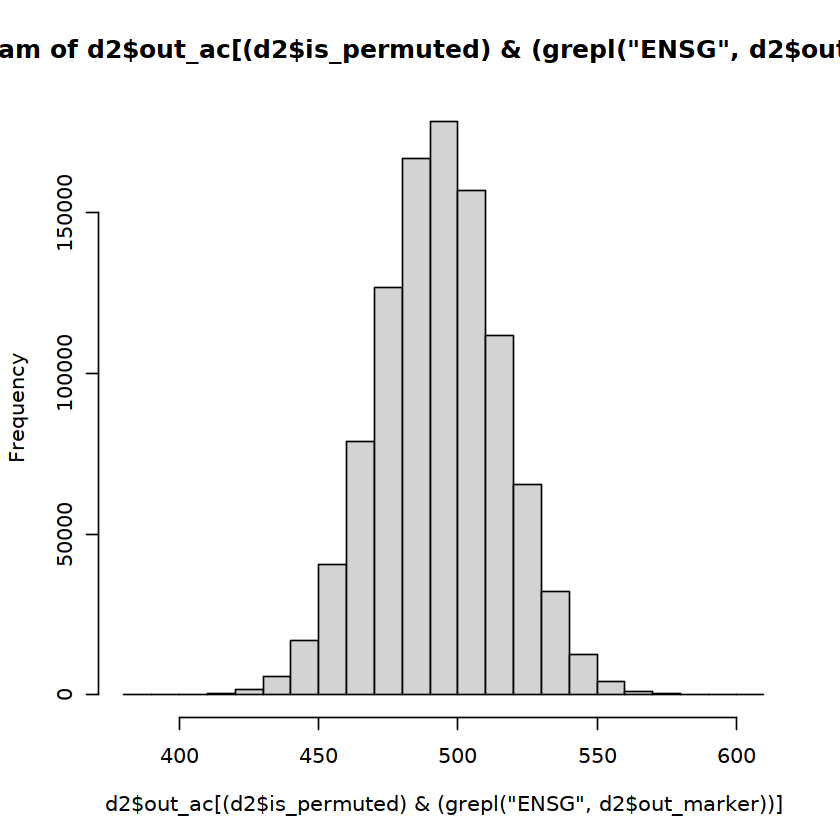

In [173]:
hist(d2$out_ac[(d2$is_permuted) & (grepl("ENSG", d2$out_marker))])

In [172]:
d2

Tstat,p,p_orig,out_marker,out_ac,is_permuted
<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>
5.780620,1.762099e-18,1.762099e-18,ENSG00000042781,NA,0
1.487070,5.046631e-01,NA,ENSG00000042781,502,1
5.485350,1.392606e-02,NA,ENSG00000042781,530,1
3.504630,1.145196e-01,NA,ENSG00000042781,468,1
3.296470,1.539591e-01,NA,ENSG00000042781,538,1
5.470190,1.442535e-02,NA,ENSG00000042781,510,1
3.461570,1.223473e-01,NA,ENSG00000042781,514,1
3.534000,1.095464e-01,NA,ENSG00000042781,506,1
5.600130,1.015057e-02,NA,ENSG00000042781,490,1


In [112]:
d2 <- fread("data/permute/permutations/chr1/ENSG00000042781/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr1_ENSG00000042781_spiro_visual_impairment_and_blindness.pvalues.tmp.txt.gz")

In [119]:
d2 <- d2[grepl("ENSG",d2$out_marker),]

In [122]:
length(unique(d2$p))

[1] 99209

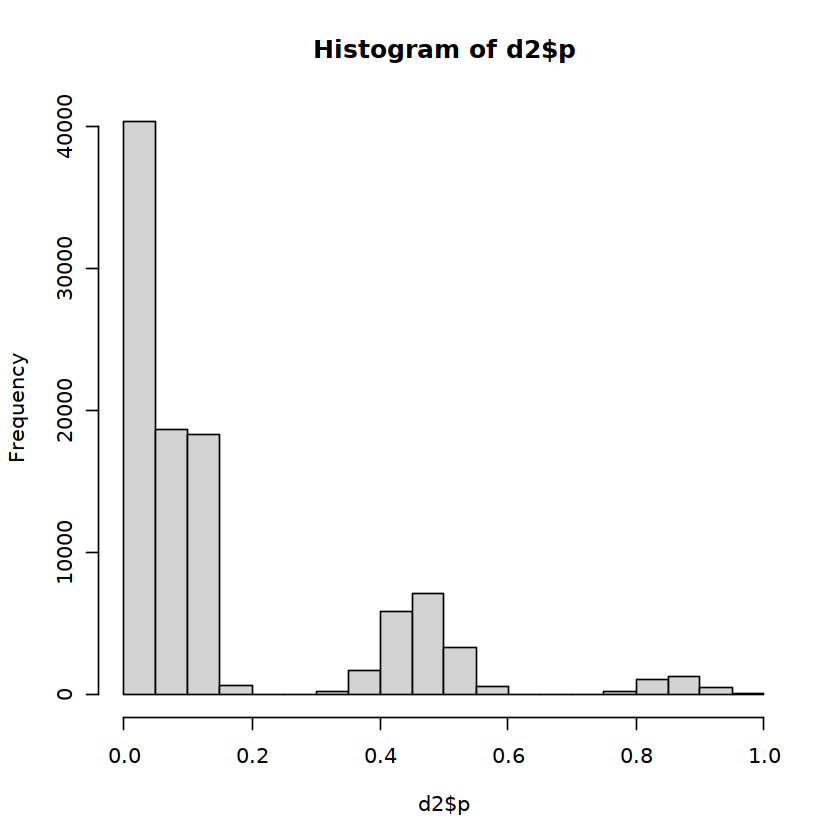

In [133]:
hist(d2$p)

In [132]:
min(d2$p[d2$is_permuted == 1])

[1] 5.546761e-05

numeric(0)

[1] 1

Tstat,p,p_orig,out_marker,out_ac,is_permuted
<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>
5.78062,1.762099e-18,1.762099e-18,ENSG00000042781,NA,0


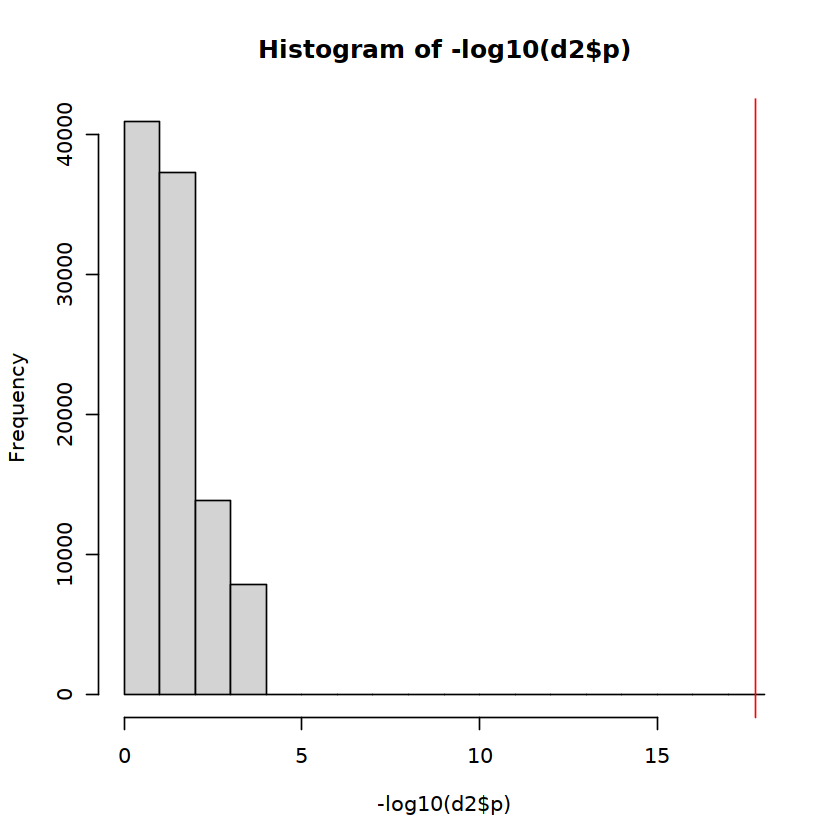

In [120]:
hist(-log10(d2$p))
abline(v = -log10(na.omit(d2$p_orig)), col = "red")
sum(d2$p %in% na.omit(d2$p_orig))
d2[d2$p %in% na.omit(d2$p_orig),]

[1] 3

In [44]:
true_p

[1] 0.8814482

In [92]:
source("scripts/post_hoc/utils.R")

In [93]:
dko <- read_ukb_wes_kos(annotation = "pLoF_damaging_missense",chromosomes = 21)

In [98]:
test <- dko[(dko$gene_id %in% "ENSG00000142156") & !(dko$knockout %in% "Heterozygote"),]
table(test$knockout)


      Compound heterozygote Compound heterozygote (cis) 
                          1                          40 
                 Homozygote 
                          1 

In [ ]:
2^

In [68]:
d1 <- fread("data/permute/genes/chr21/ukb_eur_wes_200k_pLoF_damaging_missense_chr21_ENSG00000142156.tsv.gz")

In [69]:
d1[d1$het_n >= 2 | d1$hom_alt_n >= 1,]

gene_id,s,het_n,hom_alt_n,pTKO
<chr>,<int>,<int>,<int>,<dbl>
ENSG00000142156,1268316,2,0,0.5
ENSG00000142156,1281035,2,0,0.5
ENSG00000142156,1298870,2,0,0.5
ENSG00000142156,1365482,2,0,0.5
ENSG00000142156,1510313,2,0,0.5
ENSG00000142156,1516508,2,0,0.5
ENSG00000142156,1604581,2,0,0.5
ENSG00000142156,1689332,2,0,0.5
ENSG00000142156,1850604,2,0,0.5


In [34]:
length(unique(pvalue))

[1] 1000

# 1.0 Phasing confidence thresholds by variants retained

In [183]:
breaks_log10 <- function(x) {
  low <- floor(log10(min(x)))
  high <- ceiling(log10(max(x)))

  10^(seq.int(low, high))
}

In [184]:
paths <- "data/phased/wes_union_calls/200k/shapeit5/phasing_conf/"
files <- list.files(paths, pattern = "phasingConf.txt.gz", full.names = TRUE)

In [185]:
dt <- do.call(rbind,lapply(files[1], function(f){
    d <- fread(f)
    d$AC <- as.numeric(gsub("(\\[)|(\\])", "", d$AC))
    d$max_AN <- max(d$AC)
    d$singleton <- (d$AC == 1) | (d$AC == d$max_AN)
    d$doubleton <- (d$AC == 2) | (d$AC == (d$max_AN-1))
    d$tripleton <- (d$AC == 3) | (d$AC == (d$max_AN-2))
    return(d)
}))

In [186]:
get_seq_table <- function(data){
    xs <- seq(0.50, 0.999, by = 0.001)
    ys <- unlist(lapply(xs, function(x) return(sum(data$PP > x))))
    table <- data.table(pp_cutoff = xs, retained = ys)
    solver <- function(pp) return(sum(data$PP >= pp))
    return(list(table = table, solve = solver))
}

In [187]:
ggplot_ppxn <- function(dt, main ){
    # get table of things to plot
    lst <- get_seq_table(dt)
    table <- lst$table
    f <- lst$solve
    # actually plot it
    p <- ggplot(table, aes(x=pp_cutoff, y=retained)) +
        geom_line() +
        geom_vline(xintercept = 0.99, col = "blue", linetype = 'dashed') +
        geom_hline(yintercept = f(0.99), col = "blue", linetype = 'dashed') +
        geom_vline(xintercept = 0.90, col = "red", linetype = 'dashed') +
        geom_hline(yintercept = f(0.90), col = "red", linetype = 'dashed') +
        ylab("log10(Variants retained)") +
        xlab("PP Cutoff") +
        scale_y_continuous(trans = 'log10',
                           breaks = trans_breaks('log10', function(x) 10^x),
                           labels = trans_format('log10', math_format(10^.x))) +
        theme_bw() +
        ggtitle(main) +
        theme(
            strip.text = element_text(size=16),
            axis.text=element_text(size=16),
            axis.title=element_text(size=14,face="bold"),
            plot.title = element_text(size=18, hjust=0.5),
            plot.subtitle = element_text(hjust=0.5),
            legend.position="none"
        ) 
    return(list(plt = p, data = table, p99=f(0.99), p90=f(0.90)))
}


In [191]:
p1 <- ggplot_ppxn(dt[dt$singleton == TRUE], "Singletons (MAC=1)")
p2 <- ggplot_ppxn(dt[dt$doubleton == TRUE], "Doubletons (MAC=2)")
p3 <- ggplot_ppxn(dt[dt$tripleton == TRUE], "Tripletons (MAC=3)")
p4 <- ggplot_ppxn(dt, "All (MAC>0)")

In [196]:
# how many more variants do we retain
print(p1$p90 / p1$p99)
print(p2$p90 / p2$p99)
print(p3$p90 / p3$p99)

[1] 46.82126
[1] 1.093655
[1] 1.053501


[1] 46.82126

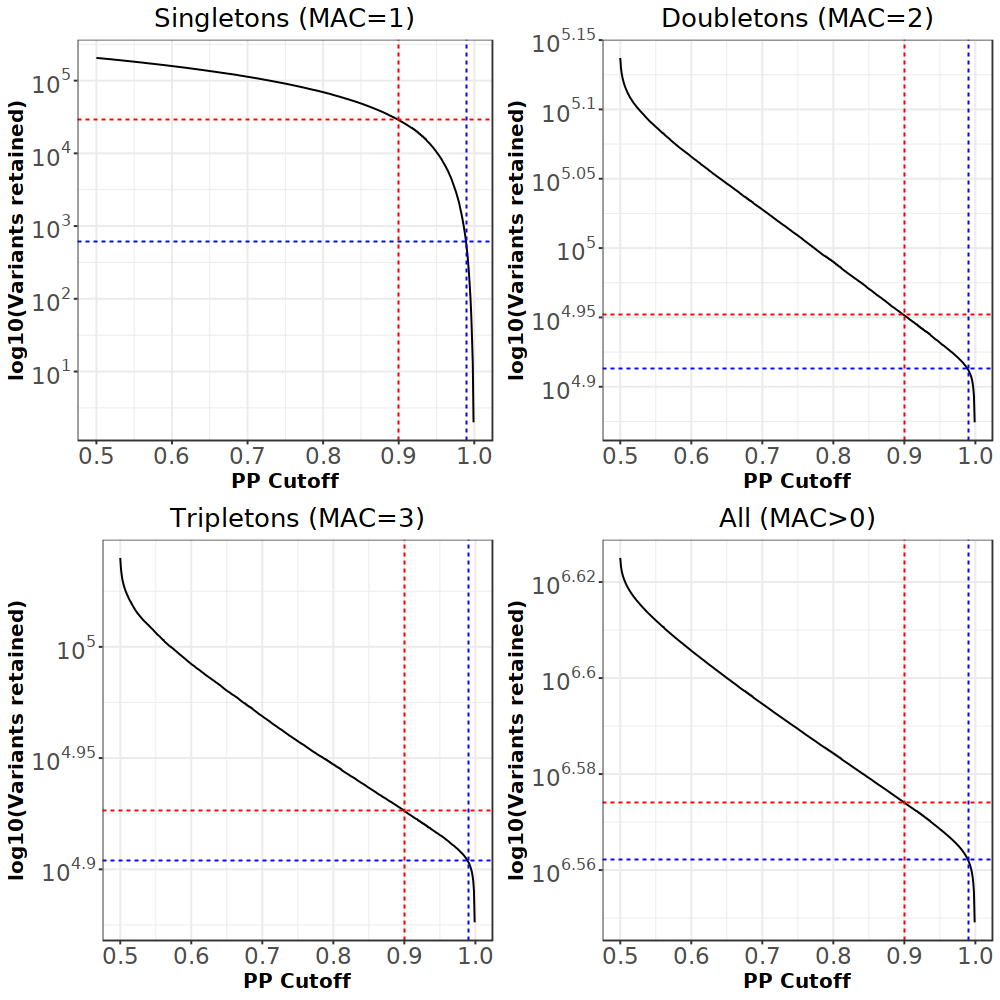

In [189]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
p <- cowplot::plot_grid(p1$plt, p2$plt, p3$plt, p4$plt, ncol = 2, nrow = 2)
print(p)

In [90]:
d1 <- p1$data
d2 <- p2$data
d3 <- p3$data
d4 <- p4$data
colnames(d1)[2] <- "retained_mac1"
colnames(d2)[2] <- "retained_mac2"
colnames(d3)[2] <- "retained_mac3"
colnames(d4)[2] <- "retained_mac4"
d <- Reduce(merge, list(d1,d2,d3,d4))

In [150]:
ggsave("derived/plots/220103_variants_retained_by_phasing_conf.pdf", p, width = 12, height = 10)
fwrite(d, "derived/plots/220103_variants_retained_by_phasing_conf.txt.gz")

# 2.0 Switch errors

# Switch error rates

In [8]:
# format infinite values
format_inf_value <- function(x){
    return(paste0(gsub("-inf","",x),"+"))
}

# make mac bins pretty
pretty_mac_bin <- function(mac_bin, split = "-"){    
    lst <- unlist(lapply(strsplit(mac_bin, split = split), function(x){
        n <- length(x)
        if (n==1){
            return(x)
        } else {
            start <- as.numeric(as.character(x[1]))
            end <- as.numeric(as.character(x[2]))
            if (start >= 1000){
                start <- tolower(scales::label_number_si()(start))
                end <- tolower(scales::label_number_si()(end))
            }
            combined <- paste0(start,'-',end)
            if (grepl("inf",combined)) combined <- format_inf_value(combined)
            return(combined)
        }

    }))
    return(lst)
}

In [9]:
switch_all <- 'data/phased/wes_union_calls/200k/shapeit5/tables/switch_error_rate/ukb_wes_union_calls_200k_shapeit5_parents_hail_chrom.txt.gz'
switch_pp90 <- 'data/phased/wes_union_calls/200k/shapeit5/tables/switch_error_rate/ukb_wes_union_calls_200k_shapeit5_parents_hail.pp90_chrom.txt.gz'



In [10]:
# get chromosomes
chroms <- paste0("chr",1:22, sep = "")

# get label
label_mapping <- c("Genotyping array", "Whole Exome Sequencing")
names(label_mapping) <- c("array", "WES")

# no pp filtering
d_all <- fread(switch_all)
d_all$wes_label <- factor(d_all$wes_label)
d_all$chr <- factor(d_all$CHR, levels = chroms)
d_all$CHR <- NULL
d_all$PP <- factor(0.50, levels = c(0.50, 0.90))
d_all$label <- label_mapping[d_all$wes_label]


# pp filtering 90
d_pp90 <- fread(switch_pp90)
d_pp90$wes_label <- factor(d_pp90$wes_label)
d_pp90$chr <- factor(d_pp90$CHR, levels = chroms)
d_pp90$CHR <- NULL
d_pp90$PP <- 0.90
d_pp90$label <- label_mapping[d_pp90$wes_label]

# combine
d <- rbind(d_all, d_pp90)

In [11]:
aggregate(switches ~ PP + wes_variant, FUN = sum, data = d)

PP,wes_variant,switches
<fct>,<lgl>,<int>
0.5,FALSE,23268
0.9,FALSE,22350
0.5,TRUE,3106
0.9,TRUE,1525


In [12]:
3106/1525


[1] 2.036721

In [13]:
d$id <- paste0(d$wes_label,": PP>=", d$PP)
d$CHR <- NULL

Warning message in set(x, j = name, value = value):
"Column 'CHR' does not exist to remove"


In [14]:
wes_colors <- c("#65B8EF", "#2266AC")
names(wes_colors) <- c("0.5", "0.9")
scale_fill_wes <- scale_fill_manual(name = "PP", values = wes_colors)

array_colors <- c("#7CA98A", "#669951")
names(array_colors) <- c("0.5", "0.9")
scale_fill_array <- scale_fill_manual(name = "PP", values = array_colors)

In [15]:
pd <- position_dodge(width = 1)
p1 <- ggplot(d[d$wes_label == "wes"],
   aes(
       x=chr,
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = PP,
       group = PP
   )) +
    theme_bw() +
    geom_bar(stat = 'identity', position = pd, size = 0.5, color = 'black') +
    geom_errorbar(stat='identity', position = pd, width = 0.75) +
    ggtitle("WES variants") +    
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Chromosomes') +
    scale_fill_wes +
    labs(fill = "Hello") +
    scale_y_continuous(breaks=scales::pretty_breaks(n=7)) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=15),
        axis.title=element_text(size=15,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 45, vjust = 0.96, hjust=0.95)
    ) 

p2 <- ggplot(d[d$wes_label == "array"],
   aes(
       x=chr,
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = PP,
       group = PP
   )) +
    theme_bw() +
    geom_bar(stat = 'identity', position = pd, size = 0.5, color = 'black') +
    geom_errorbar(stat='identity', position = pd, width = 0.75) +
    ggtitle("Genotyping array variants") +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Chromosomes') +
    scale_fill_array +
    labs(fill = "Hello") +
    scale_y_continuous(breaks=scales::pretty_breaks(n=7)) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=15),
        axis.title=element_text(size=15,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 45, vjust = 0.96, hjust=0.95)
    ) 

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."


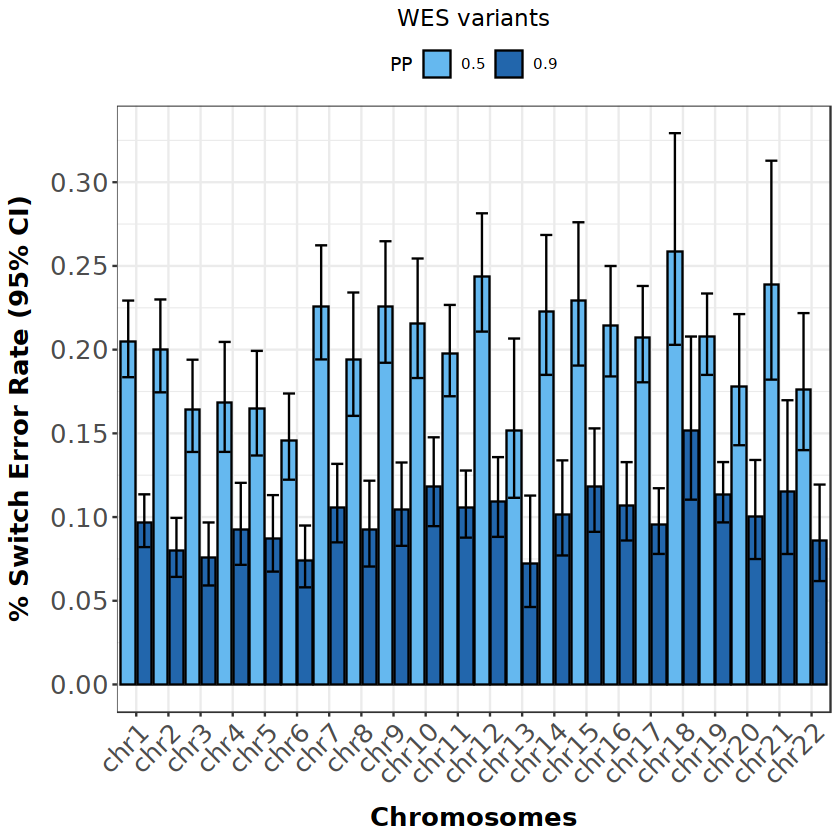

In [16]:
p1
out_prefix <- "derived/plots/230103_phasing_errors_wes"
#ggsave(paste0(out_prefix, ".pdf"), p1, width = 14, height = 7)

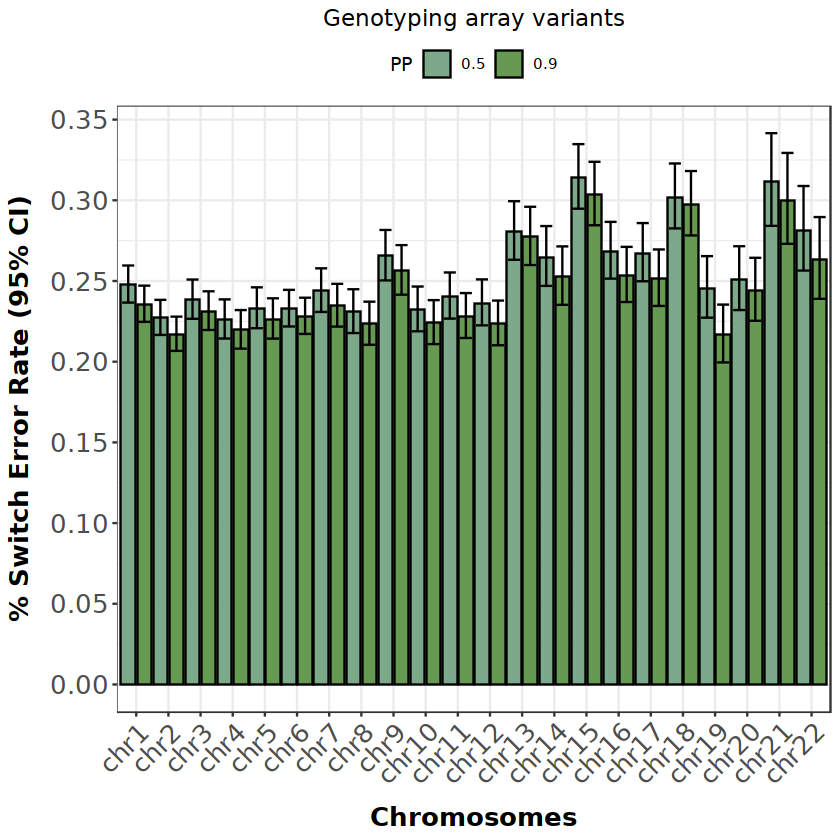

In [17]:
p2
out_prefix <- "derived/plots/230103_phasing_errors_array"
#ggsave(paste0(out_prefix, ".pdf"), p2, width = 14, height = 7)

In [18]:
#d_all$pointest <- round(d_all$pointest, 4)
#d_all$upper <- round(d_all$upper, 4)
#d_all$lower <- round(d_all$lower, 4)

#d_pp90$pointest <- round(d_pp90$pointest, 4)
#d_pp90$upper <- round(d_pp90$upper, 4)
#d_pp90$lower <- round(d_pp90$lower, 4)

In [19]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
colnames(d_all)[2:6] <- paste0("PP_all_", colnames(d_all)[2:6])
colnames(d_pp90)[2:6] <- paste0("PP_90_", colnames(d_pp90)[2:6])
d_all$PP <- NULL
d_pp90$PP <- NULL

In [20]:
head(d_all)

wes_variant,PP_all_switches,PP_all_tested,PP_all_pointest,PP_all_lower,PP_all_upper,wes_label,chr,label
<lgl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<chr>
FALSE,1782,718976,0.002478525,0.002366219,0.002596148,array,chr1,Genotyping array
TRUE,309,150616,0.002051575,0.001835412,0.002293137,wes,chr1,Whole Exome Sequencing
FALSE,1077,463637,0.002322938,0.002188430,0.002465693,array,chr10,Genotyping array
TRUE,141,65332,0.002158207,0.001830440,0.002544516,wes,chr10,Whole Exome Sequencing
FALSE,1086,451432,0.002405678,0.002266945,0.002552879,array,chr11,Genotyping array
TRUE,202,102246,0.001975627,0.001721526,0.002267150,wes,chr11,Whole Exome Sequencing


In [22]:
mrg <- merge(d_all, d_pp90, by = c("wes_variant","wes_label", "chr", "label"))
mrg$tested_difference <- mrg$PP_all_tested - mrg$PP_90_tested
mrg$switch_difference <- mrg$PP_all_switches - mrg$PP_90_switches
mrg$wes_variant <- NULL
mrg$wes_label <- NULL
mrg <- mrg[order(mrg$chr),]
#fwrite(mrg, "derived//tables/221226_switch_error_rate_by_chrom.txt", sep = "\t")


## 2.1 Switch errors by mac bins:

In [23]:
switch_all <- 'data/phased/wes_union_calls/200k/shapeit5/tables/switch_error_rate/ukb_wes_union_calls_200k_shapeit5_parents_hail_mac.txt.gz'
switch_pp90 <- 'data/phased/wes_union_calls/200k/shapeit5/tables/switch_error_rate/ukb_wes_union_calls_200k_shapeit5_parents_hail.pp90_mac.txt.gz'

In [24]:
# no pp filtering
d_all <- fread(switch_all)
bins_all <- unique(d_all$mac_bin)
d_all$mac_bin_pretty <- pretty_mac_bin(d_all$mac_bin)
d_all$mac_bin_pretty <- factor(d_all$mac_bin_pretty, levels = unique(d_all$mac_bin_pretty))
d_all$mac_bin <- factor(d_all$mac_bin, levels = unique(d_all$mac_bin))
d_all$PP <- 0.50

# pp filtering 90
d_pp90 <- fread(switch_pp90)
bins_pp90 <- unique(d_pp90$mac_bin)
d_pp90$mac_bin_pretty <- pretty_mac_bin(d_pp90$mac_bin)
d_pp90$mac_bin_pretty <- factor(d_pp90$mac_bin_pretty, levels = unique(d_pp90$mac_bin_pretty))
d_pp90$mac_bin <- factor(d_pp90$mac_bin, levels = unique(d_pp90$mac_bin))
d_pp90$PP <- 0.90

Warning message:
"`label_number_si()` was deprecated in scales 1.2.0.
i Please use the `scale_cut` argument of `label_number()` instead."


In [25]:
d_all <- d_all[d_all$wes_label == "wes",]
d_pp90 <- d_pp90[d_pp90$wes_label == "wes",]

In [26]:
d <- rbind(d_all, d_pp90)
d$PP <- factor(d$PP)

In [27]:
my_colors <- c("#65B8EF", "#2266AC")
names(my_colors) <- c("0.5", "0.9")
fill_scale2 <- scale_fill_manual(name = "PP", values = my_colors)
color_scale2 <- scale_color_manual(name = "PP", values = my_colors)

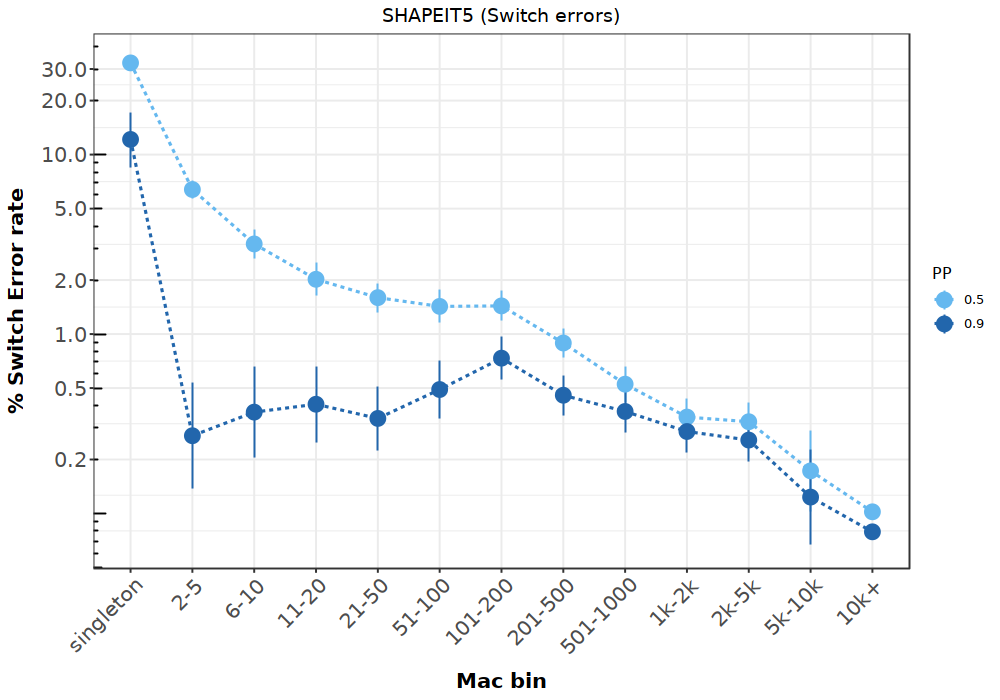

In [28]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 100)
p_trio <- ggplot(d,
   aes(
       x=mac_bin_pretty,
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       color = PP,
       group = PP,
   )) +
    theme_bw() +
    geom_line(linetype = "dashed", size = 0.8) +
    geom_pointrange(size=0.95) +
    ylab('% Switch Error rate') + 
    xlab('Mac bin') +
    color_scale2 +
    labs(color = "Variant origin") +
    scale_y_continuous(trans = 'log10', breaks=c(0.2, 0.5, 1, 2, 5, 10, 20, 30, 50)) +    
    annotation_logticks(sides='l')  +
    theme(
        legend.position = "right",
        axis.text=element_text(size=15),
        axis.title=element_text(size=15,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 45, vjust = 0.96, hjust=0.95)
    ) +
    ggtitle("SHAPEIT5 (Switch errors)")
p_trio

In [30]:
# save plot
out_prefix <- "derived/plots/230103_trio_switch_errors_small"
ggsave(paste0(out_prefix, ".pdf"), p_trio, width = 9, height = 6)
fwrite(d, paste0(out_prefix, ".txt"))

In [204]:
colnames(d_all)[3:7] <- paste0("PP_all_", colnames(d_all)[3:7])
colnames(d_pp90)[3:7] <- paste0("PP_90_", colnames(d_pp90)[3:7])
d_all$PP <- NULL
d_pp90$PP <- NULL
head(d_pp90)

wes_variant,mac_bin,PP_90_switches,PP_90_tested,PP_90_pointest,PP_90_lower,PP_90_upper,wes_label,mac_bin_pretty
<lgl>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
TRUE,singleton,26,214,0.121495327,0.084275504,0.172064400,wes,singleton
TRUE,2-5,8,2949,0.002712784,0.001375254,0.005344192,wes,2-5
TRUE,6-10,11,2995,0.003672788,0.002052091,0.006565057,wes,6-10
TRUE,11-20,16,3937,0.004064008,0.002503147,0.006591728,wes,11-20
TRUE,21-50,22,6495,0.003387221,0.002238003,0.005123533,wes,21-50
TRUE,51-100,28,5704,0.004908836,0.003398531,0.007085548,wes,51-100


In [205]:
mrg <- merge(d_all, d_pp90, by = c("wes_variant","wes_label", "mac_bin", "mac_bin_pretty"))
mrg$wes_variant <- NULL
mrg$mac_bin <- NULL
mrg <- mrg[order(mrg$mac_bin_pretty),]
mrg
#fwrite(mrg, "derived//tables/221226_switch_error_rate_by_chrom.txt", sep = "\t")

wes_label,mac_bin_pretty,PP_all_switches,PP_all_tested,PP_all_pointest,PP_all_lower,PP_all_upper,PP_90_switches,PP_90_tested,PP_90_pointest,PP_90_lower,PP_90_upper
<chr>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
wes,singleton,569,1754,0.324401368,0.3028968753,0.346673342,26,214,0.1214953271,0.0842755044,0.1720644005
wes,2-5,248,3880,0.063917526,0.0566439682,0.072053731,8,2949,0.0027127840,0.0013752544,0.0053441916
wes,6-10,106,3334,0.031793641,0.0263560616,0.038308921,11,2995,0.0036727880,0.0020520907,0.0065650566
wes,11-20,85,4209,0.020194821,0.0163621901,0.024902467,16,3937,0.0040640081,0.0025031468,0.0065917278
wes,21-50,108,6768,0.015957447,0.0132348443,0.019229214,22,6495,0.0033872209,0.0022380032,0.0051235334
wes,51-100,84,5890,0.014261460,0.0115345461,0.017621559,28,5704,0.0049088359,0.0033985308,0.0070855479
wes,101-200,102,7106,0.014354067,0.0118392238,0.017393701,51,6949,0.0073391855,0.0055867222,0.0096360410
wes,201-500,117,13123,0.008915644,0.0074448966,0.010673815,59,12934,0.0045616205,0.0035383049,0.0058791438
wes,501-1000,71,13506,0.005256923,0.0041701182,0.006625083,50,13499,0.0037039781,0.0028108657,0.0048794756


In [208]:
mrg$reduction <- mrg$PP_all_pointest / mrg$PP_90_pointest 
mrg

wes_label,mac_bin_pretty,PP_all_switches,PP_all_tested,PP_all_pointest,PP_all_lower,PP_all_upper,PP_90_switches,PP_90_tested,PP_90_pointest,PP_90_lower,PP_90_upper,reduction
<chr>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
wes,singleton,569,1754,0.324401368,0.3028968753,0.346673342,26,214,0.1214953271,0.0842755044,0.1720644005,2.670073
wes,2-5,248,3880,0.063917526,0.0566439682,0.072053731,8,2949,0.0027127840,0.0013752544,0.0053441916,23.561598
wes,6-10,106,3334,0.031793641,0.0263560616,0.038308921,11,2995,0.0036727880,0.0020520907,0.0065650566,8.656541
wes,11-20,85,4209,0.020194821,0.0163621901,0.024902467,16,3937,0.0040640081,0.0025031468,0.0065917278,4.969188
wes,21-50,108,6768,0.015957447,0.0132348443,0.019229214,22,6495,0.0033872209,0.0022380032,0.0051235334,4.711074
wes,51-100,84,5890,0.014261460,0.0115345461,0.017621559,28,5704,0.0049088359,0.0033985308,0.0070855479,2.905263
wes,101-200,102,7106,0.014354067,0.0118392238,0.017393701,51,6949,0.0073391855,0.0055867222,0.0096360410,1.955812
wes,201-500,117,13123,0.008915644,0.0074448966,0.010673815,59,12934,0.0045616205,0.0035383049,0.0058791438,1.954491
wes,501-1000,71,13506,0.005256923,0.0041701182,0.006625083,50,13499,0.0037039781,0.0028108657,0.0048794756,1.419264


In [112]:
switch_all <- 'data/phased/wes_union_calls/200k/shapeit5/tables/switch_error_rate/ukb_wes_union_calls_200k_shapeit5_parents_hail_mac.txt.gz'
switch_pp90 <- 'data/phased/wes_union_calls/200k/shapeit5/tables/switch_error_rate/ukb_wes_union_calls_200k_shapeit5_parents_hail.pp90_mac.txt.gz'

# Number of completely phased genes

In [113]:
switch_pp90 <- 'data/phased/wes_union_calls/200k/shapeit5/tables/switch_error_rate/ukb_wes_union_calls_200k_shapeit5_parents_hail.pp90_gene.txt.gz'
switch_all <- 'data/phased/wes_union_calls/200k/shapeit5/tables/switch_error_rate/ukb_wes_union_calls_200k_shapeit5_parents_hail_gene.txt.gz'

In [114]:
get_gene_table <- function(d) {
    return(data.table(
        chromosome = unique(d$chr),
        n_genes = length(unique(d$gene)),
        n_genes_perfect_phased = sum(d$errors == 0),
        n_genes_with_errors = sum(d$errors > 0),
        pct_perfectly_phased = sum(d$errors == 0)/length(unique(d$gene)),
        mean_variants_per_gene = mean(d$sites),
        mean_errors_per_gene = mean(d$errors)
    ))
}

In [115]:
chromosomes <- paste0("chr",1:22)





In [116]:
d_pp90 <- fread(switch_pp90)
d <- d_pp90
d <- d[d$sites > 0,]
d$chr <- factor(d$chr, levels = chromosomes)
lst <- lapply(chromosomes, function(chrom) get_gene_table(d[d$chr %in% chrom,]))
d_chrom <- do.call(rbind, lst)
d$chr <- "Total"
d_total <- get_gene_table(d)
out1 <- rbind(d_chrom, d_total)


In [117]:
d_all <- fread(switch_all)
d <- d_all
d <- d[d$sites > 0,]
d$chr <- factor(d$chr, levels = chromosomes)
lst <- lapply(chromosomes, function(chrom) get_gene_table(d[d$chr %in% chrom,]))
d_chrom <- do.call(rbind, lst)
d$chr <- "Total"
d_total <- get_gene_table(d)
out2 <- rbind(d_chrom, d_total)


In [118]:
cbind(out2, out1)

chromosome,n_genes,n_genes_perfect_phased,n_genes_with_errors,pct_perfectly_phased,mean_variants_per_gene,mean_errors_per_gene,chromosome,n_genes,n_genes_perfect_phased,n_genes_with_errors,pct_perfectly_phased,mean_variants_per_gene,mean_errors_per_gene
<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
chr1,2150,1880,270,0.8744186,81.19023,0.1632558,chr1,2142,2012,130,0.9393091,81.26937,0.07329599
chr2,1367,1199,168,0.8771031,89.44770,0.1726408,chr2,1362,1291,71,0.9478708,89.52203,0.06240822
chr3,1219,1081,138,0.8867925,82.28056,0.1460213,chr3,1217,1146,71,0.9416598,82.21775,0.06573541
chr4,782,690,92,0.8823529,90.60614,0.1508951,chr4,779,724,55,0.9293967,90.74069,0.08600770
chr5,965,844,121,0.8746114,106.52021,0.1875648,chr5,962,904,58,0.9397089,106.61019,0.06964657
chr6,1123,1002,121,0.8922529,92.32769,0.1308994,chr6,1116,1050,66,0.9408602,92.74014,0.06810036
chr7,981,852,129,0.8685015,87.32212,0.1875637,chr7,980,909,71,0.9275510,87.19694,0.09081633
chr8,727,639,88,0.8789546,88.95461,0.1636864,chr8,721,673,48,0.9334258,89.48405,0.07905687
chr9,825,712,113,0.8630303,93.09091,0.2012121,chr9,824,764,60,0.9271845,92.92597,0.09344660


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



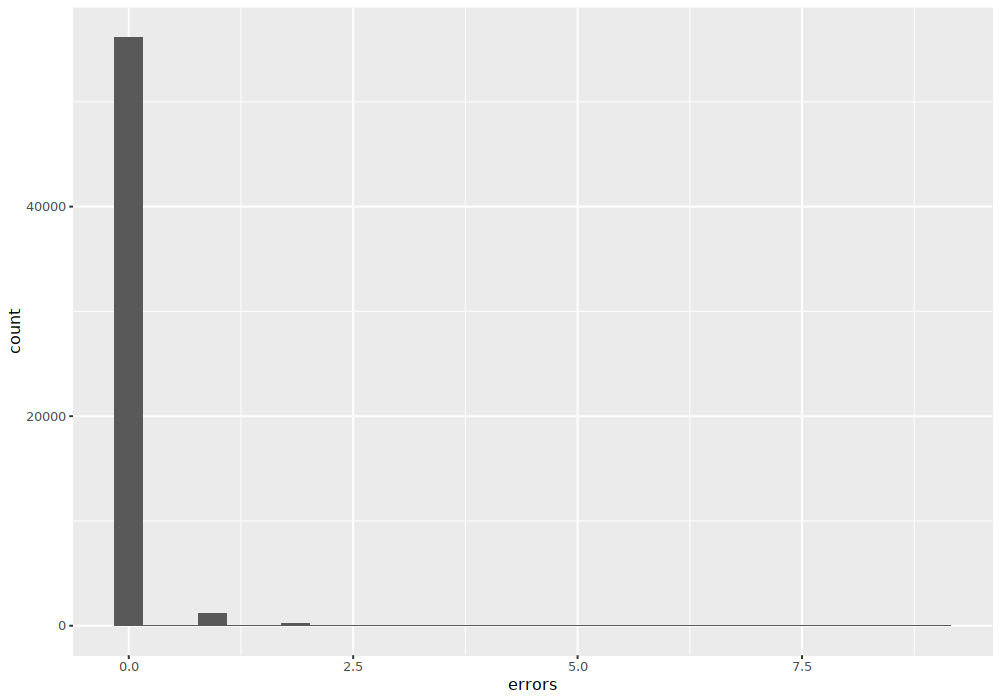

In [119]:
ggplot(d_pp90, aes(x=errors)) +
    geom_histogram() 

# Read backed Phasing

In [121]:
fread_rb <- function(f){
    bname <- basename(f)
    pp <- stringr::str_extract(bname, "pp[0-9]+")
    pp <- as.numeric(gsub("pp","",pp))
    if (!grepl('singleton', bname)){
        bin <- stringr::str_extract(bname, "mac_bin.[0-9]+_[0-9]+")
        bin <- gsub("mac_bin.","",bin)
    } else {
        bin <- "singleton"
    }
    d <- fread(f)
    d$PP <- as.numeric(pp) / 100
    d$bin <- bin
    return(d)
}

bin_conf <- function(counts){
    counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$match[i], counts$total[i])))
    colnames(counts_ci) <- tolower(colnames(counts_ci))
    counts <- cbind(counts, counts_ci)
    return(counts)
}


eval_phase <- function(full, labels){
    sums <- aggregate(match ~ bin, data = full, FUN = sum)
    lens <- aggregate(match ~ bin, data = full, FUN = length)
    colnames(lens)[2] <- "total"
    mrg <- merge(sums, lens)
    mrg <- mrg[match(labels, mrg$bin), ]
    mrg <- mrg[!is.na(mrg$bin),]
    mrg$errors <- mrg$total - mrg$match
    mrg <- bin_conf(mrg)
    return(mrg)
}
                                       
# format infinite values
format_inf_value <- function(x){
    return(paste0(gsub("-inf","",x),"+"))
}

# make mac bins pretty
pretty_mac_bin <- function(mac_bin, split = "-"){    
    lst <- unlist(lapply(strsplit(mac_bin, split = split), function(x){
        n <- length(x)
        if (n==1){
            return(x)
        } else {
            start <- as.numeric(as.character(x[1]))
            end <- as.numeric(as.character(x[2]))
            if (start >= 1000){
                start <- tolower(scales::label_number_si()(start))
                end <- tolower(scales::label_number_si()(end))
            }
            combined <- paste0(start,'-',end)
            if (grepl("inf",combined)) combined <- format_inf_value(combined)
            return(combined)
        }

    }))
    return(lst)
}

In [122]:
library(data.table)
files <- list.files("data/prephased/wes_union_calls/test/", pattern = "161222", full.names = TRUE)
#files <- files[!grepl('singleton', files)]
#length(files)

In [123]:
# load data 
rb <- do.call(rbind, lapply(files, fread_rb))

In [124]:
# we match using these labels
bins <- c(0,1,5,10,20,50,100,200,500,1000,2000,5000,10000, Inf)
labels <- unlist(lapply(2:length(bins), function(i){paste0(bins[i-1]+1,"_",bins[i])}))
labels[labels == '1_1'] <- "singleton"

In [125]:
# load data 
rb <- do.call(rbind, lapply(files, fread_rb))

In [126]:
# get CIs
rb <- do.call(rbind, lapply(unique(rb$PP), function(pp){
    rb_subset <- rb[rb$PP == pp,]
    x <- eval_phase(rb_subset, labels)
    x$PP <- pp
    return(x)
}))

# convert to pct
rb$pointest <- rb$pointest * 100
rb$lower <- rb$lower * 100
rb$upper <- rb$upper * 100

In [127]:
rb$mac_bin <- pretty_mac_bin(rb$bin, split = '_')

In [128]:
rb$mac_bin <- factor(rb$mac_bin, levels = unique(rb$mac_bin))
rb$PP <- factor(rb$PP)

In [129]:
my_colors <- c("#2266AC", "#65B8EF")
names(my_colors) <- c("0.9", "0.5")
fill_scale2 <- scale_fill_manual(name = "PP", values = my_colors)
color_scale2 <- scale_color_manual(name = "PP", values = my_colors)

In [130]:
# we only care about low MAF
rb <- rb[!(rb$bin %in% c("2001_5000","5001_10000")),]

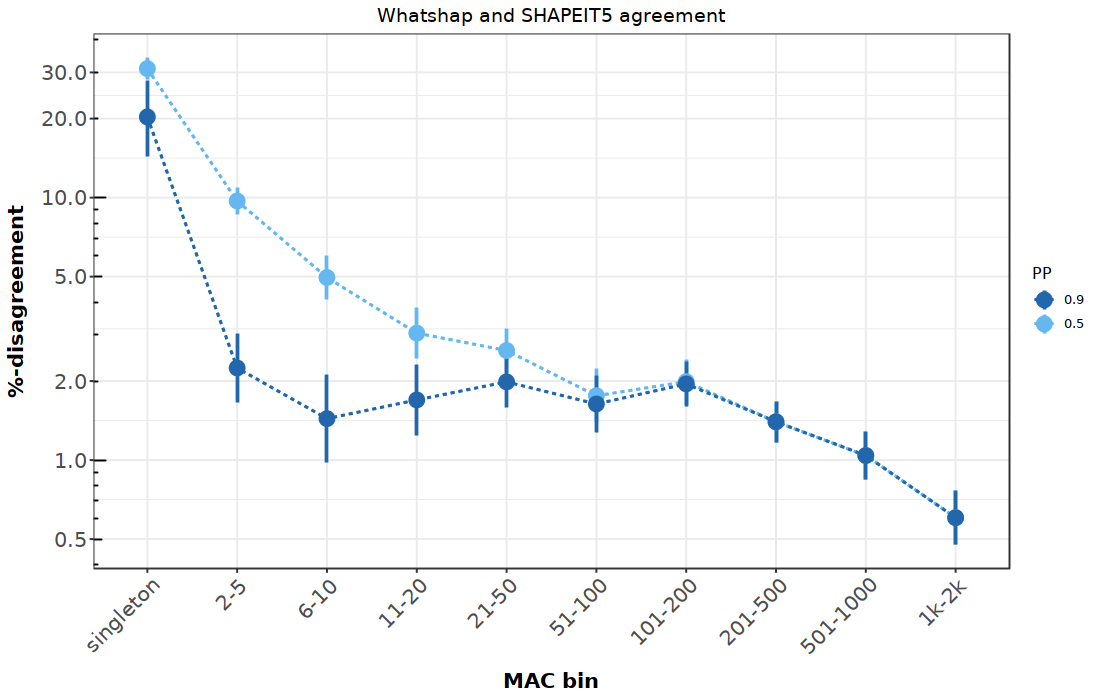

In [131]:
options(repr.plot.width = 11, repr.plot.height = 7, repr.plot.res = 100)
pd <- position_dodge(width = 0.55)
rb_selected <- rb[rb$PP %in% c("0.5","0.9"),]
p_rb <- ggplot(rb_selected, aes(x=mac_bin, y=100-pointest, ymin=100-lower, ymax=100-upper, color = PP, group = PP)) +
    color_scale2 +
    geom_line(linetype = 'dashed') +
    theme_bw() +
    theme(
        legend.position = "right",
        axis.text=element_text(size=15),
        axis.title=element_text(size=15,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 45, vjust = 0.96, hjust=0.95)
    ) +
    scale_y_continuous(trans = 'log10', breaks=c(0.2, 0.5, 1, 2, 5, 10, 20, 30, 50)) +    
    annotation_logticks(sides='l')  +
    geom_line(linetype = "dashed", size = 0.8) +
    geom_pointrange(size = 0.95) +
    xlab("MAC bin") +
    ylab("%-disagreement") +
    labs(color = "Phasing Confidence")+
    ggtitle("Whatshap and SHAPEIT5 agreement")

p_rb 

In [132]:
# save plot
out_prefix <- "derived/plots/230103_rb_errors"
ggsave(paste0(out_prefix, ".pdf"), p_rb, width = 10, height = 7)
fwrite(rb_selected, paste0(out_prefix, ".txt"))

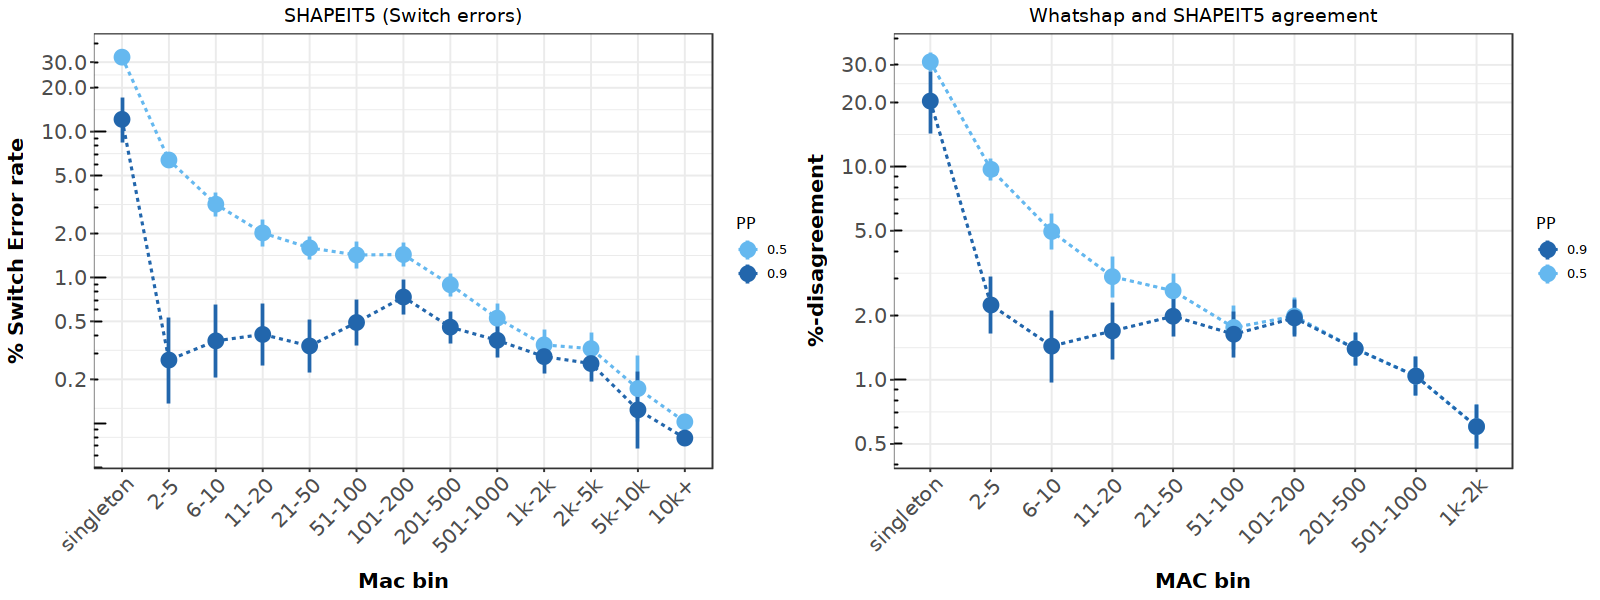

In [133]:
options(repr.plot.width = 16, repr.plot.height = 6, repr.plot.res = 100)
p_combined <- plot_grid(p_trio, p_rb, labels = NULL, label_size = 12)
p_combined

In [148]:
out_prefix <- "derived/plots/230103_trio_and_rb_errors"
ggsave(paste0(out_prefix, ".pdf"), p_combined, width = 18, height = 7)
fwrite(rb_selected, paste0(out_prefix, ".txt"))

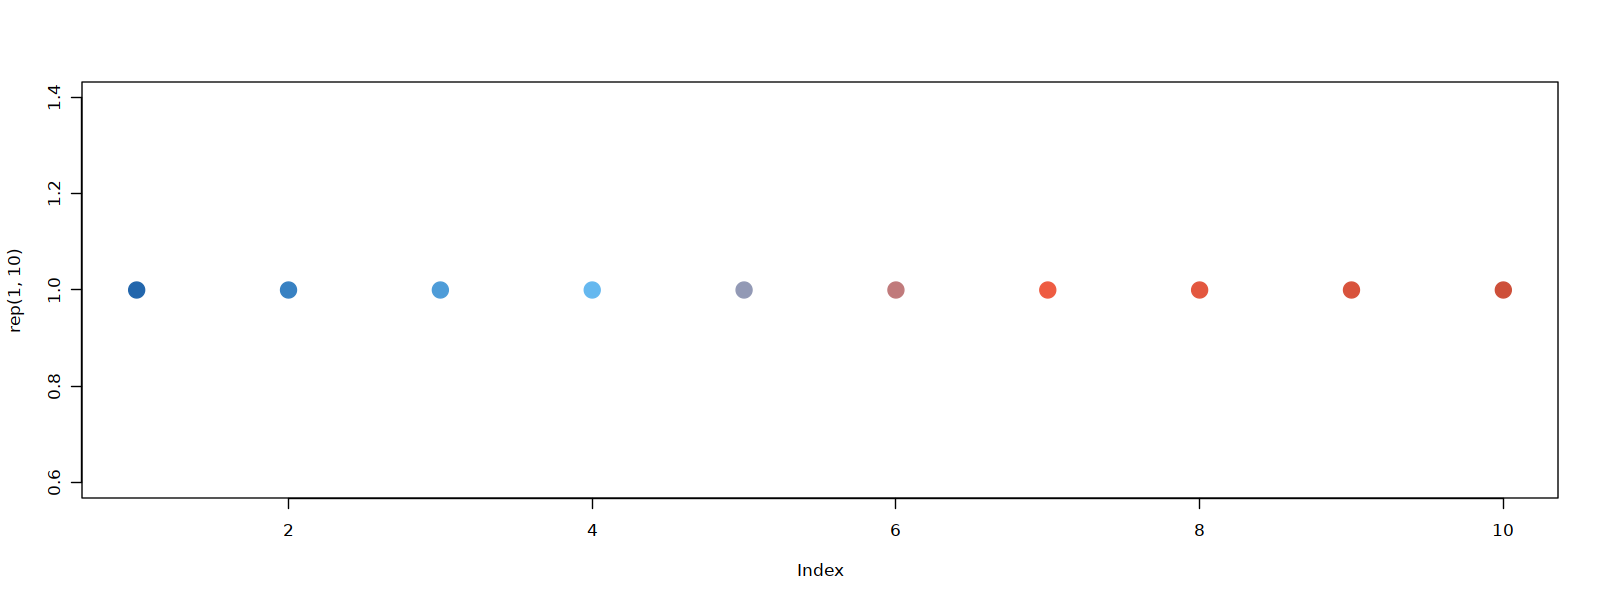

In [135]:
colfunc<-colorRampPalette(c("#2266AC", "#65B8EF","tomato2","tomato3"))#))
plot(rep(1,10),col=(colfunc(10)), pch=19,cex=2)
colors <- colfunc(5)

In [136]:
pps <- levels(rb$PP)
my_colors <- rev(colfunc(length(pps)))
names(my_colors) <- pps
color_scale <- scale_color_manual(name = "PP", values = my_colors)

Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Transformation introduced infinite values in continuous y-axis"


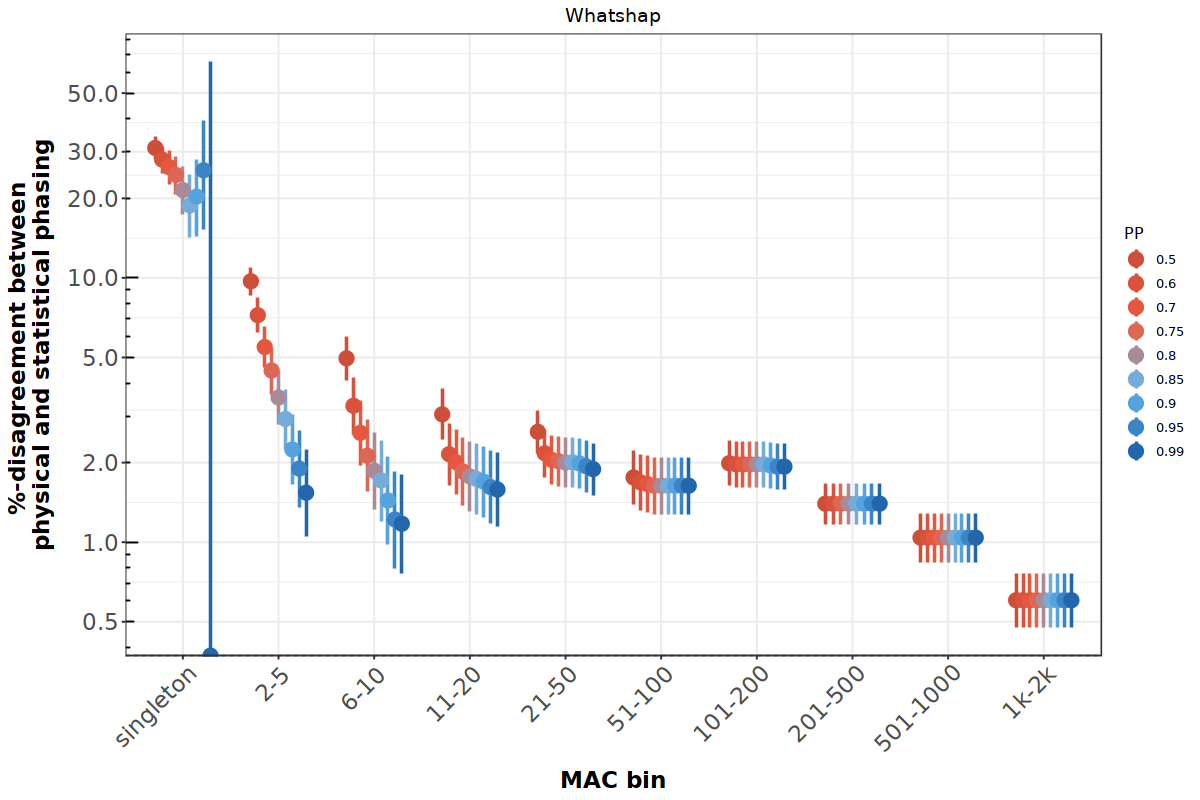

In [137]:
options(repr.plot.width = 12, repr.plot.height = 8, repr.plot.res = 100)
pd <- position_dodge(width = 0.65)
p1 <- ggplot(rb, aes(x=mac_bin, y=100-pointest, ymin=100-lower, ymax=100-upper, color = PP, group = PP)) +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Mac bin') +
    color_scale +
    theme_bw() +
    theme(
        legend.position = "right",
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 45, vjust = 0.96, hjust=0.95)
    ) +
    scale_y_continuous(trans = 'log10', breaks=c(0.2, 0.5, 1, 2, 5, 10, 20, 30, 50)) + #breaks=c(0.01, 0.02, 0.05, 0.1, 0.30, 1)) +    
    annotation_logticks(sides='l')  +
    geom_hline(yintercept = 0, linetype = 'dashed', alpha = 0.5) +
    geom_pointrange(position = pd, size = 0.90) +
    #coord_cartesian(ylim = c(0.5, 1)) +
    #scale_color_brewer(palette = "RdBu") +
    xlab("MAC bin") +
    ylab("%-disagreement between \nphysical and statistical phasing") +
    labs(color = "Phasing Confidence")+
    ggtitle("Whatshap")


print(p1)


In [138]:
out_prefix <- "derived/plots/230103_rb_errors_by_phase_conf"
ggsave(paste0(out_prefix, ".pdf"), p1, width = 10, height = 7)
fwrite(rb, paste0(out_prefix, ".txt"))

Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Transformation introduced infinite values in continuous y-axis"


In [139]:
# back to original scale
rb_out <- rb
rb_out$pointest <- 1-(rb_out$pointest )
rb_out$lower <- 1-(rb_out$lower )
rb_out$upper <- 1-(rb_out$upper )
rb_out <- rb_out[order(rb_out$mac_bin),]
rownames(rb_out) <- NULL
#rb_out[,c("mac_bin","PP","total","errors", "pointest", "lower", "upper")] # the table here <----

# Read backed phasing evaluation of variants that can be recovered

In [140]:
library(data.table)
files <- list.files("data/prephased/wes_union_calls/test/", pattern = "161222", full.names = TRUE)
rb <- do.call(rbind, lapply(files, fread_rb))

In [141]:
rb$pos_max_pp <- as.numeric(gsub("\\:","",stringr::str_extract(rb$rsid_max_pp, ":[0-9]+:")))
rb$pos_min_pp <- as.numeric(gsub("\\:","",stringr::str_extract(rb$rsid_min_pp, ":[0-9]+:")))
rb$dist <- abs(rb$pos_max_pp-rb$pos_min_pp)
rb$PP <- factor(rb$PP)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



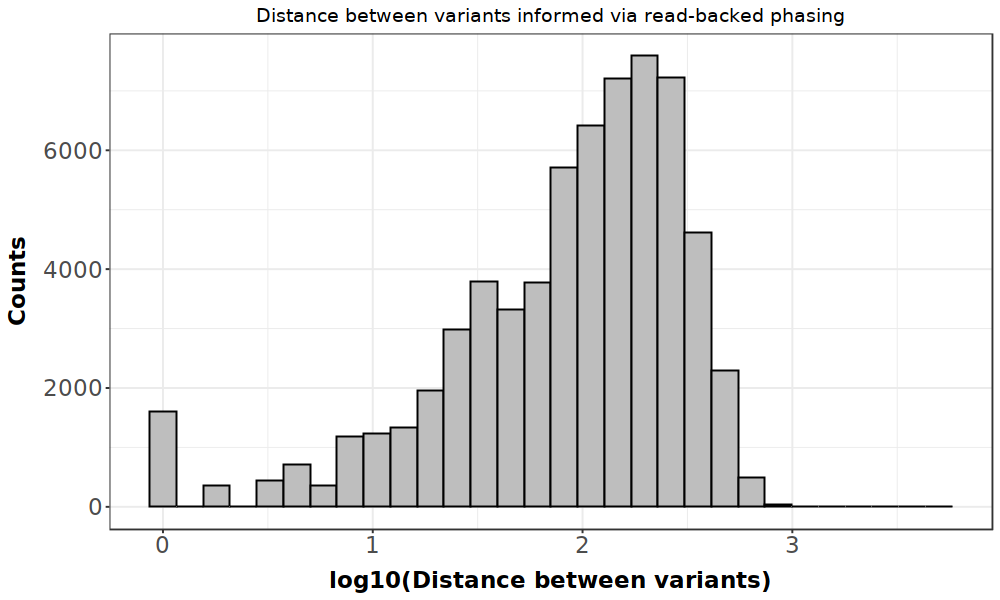

In [142]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 100)
p1 <- ggplot(rb[rb$PP == 0.50], aes(x=log10(dist))) + 
    geom_histogram(color='black', fill='grey') +
    ggtitle("Distance between variants informed via read-backed phasing") +
    xlab("log10(Distance between variants)") +
    ylab("Counts") +
    theme_bw() +
    theme(
        legend.position = "right",
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
    )
p1

In [143]:
out_prefix <- "derived/plots/230103_rb_rsid_distance"
ggsave(paste0(out_prefix, ".pdf"), p1, width = 10, height = 7)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



In [144]:
mac_range <- 1:10
cutoff_pp <- 0.99

In [145]:
do.call(rbind,lapply(mac_range, function(mac){
   rb1 <- rb[(rb$min_mac == mac) & (rb$min_pp < cutoff_pp),]
   samples <- length(unique(rb1$sid))
   unique_variants <- length(unique(rb1$rsid_min_pp))
   rows <- nrow(rb1)
   pass <- sum(rb1$max_pp >= cutoff_pp)
   frac <- pass/rows
   dt <- data.table(
       mac = mac,
       pp_cutoff = cutoff_pp,
       unique_samples = samples,
       unique_variants = unique_variants,
       variants = rows,
       can_be_informed = pass,
       fraction_informed = paste0(round(frac*100, 2),'%')
   )
   return(dt)
}))



mac,pp_cutoff,unique_samples,unique_variants,variants,can_be_informed,fraction_informed
<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>
1,0.99,854,891,3665,3377,92.14%
2,0.99,304,303,1242,1203,96.86%
3,0.99,196,193,811,768,94.7%
4,0.99,148,144,603,565,93.7%
5,0.99,118,118,600,582,97%
6,0.99,86,85,424,423,99.76%
7,0.99,66,66,320,304,95%
8,0.99,42,40,198,198,100%
9,0.99,57,55,262,253,96.56%


# Chunks by SHAPEIT4 and Eagle2

In [21]:
fread_phased_sites <- function(file, ...){

    # get details about chunks
    bname <- basename(file)
    method <- unlist(strsplit(bname, split = '_'))[6]

    # append to data.table
    d <- fread(file, ...)
    cnames <- colnames(d)
    d$AC <- d$info.AC
    d$AN <- d$info.AN
    d$info.AC <- NULL
    d$info.AN <- NULL

    # check that columns are OK
    d$AN_m_AC <- as.numeric(d$AN - d$AC)
    d$MAC <- as.numeric(apply(d[,c("AC","AN_m_AC")], 1, min))
    d$locus <- paste0(d$CHR,":",d$POS)
    d$method <- method
    return(d)

}

# aggregate switch errors by chromosome and minor allele frequency bins
aggregate_by_chrom <- function(files, variants){
    lst <- lapply(files, function(file){
        d <- fread_phased_sites(file)
        d$wes_variant <- d$locus %in% variants$locus
        counts <- aggregate(switches ~ wes_variant + CHR, data = d, FUN = sum)
        tested <- aggregate(switches ~ wes_variant + CHR, data = d, FUN = length)
        counts <- data.table(counts, tested = tested$switches)
        return(counts)
    })
    return(lst)
}

# aggregate by MAC by CHROM
aggregate_by_mac_chrom <- function(files, mac_bins, mac_bins_labels, variants){
    stopifnot((length(mac_bins)-1) == length(mac_bins_labels))
    stopifnot(all(mac_bins>=0))
    lst <- lapply(files, function(file){
        d <- fread_phased_sites(file)
        d$wes_variant <- d$locus %in% variants$locus
        d$mac_bin <- cut(d$MAC, breaks = mac_bins, labels = mac_bins_labels)
        counts <- aggregate(switches ~ wes_variant + mac_bin + CHR, data = d, FUN = sum)
        tested <- aggregate(switches ~ wes_variant + mac_bin + CHR, data = d, FUN = length)
        counts <- data.table(counts, tested = tested$switches)
        return(counts)
    })
    return(lst)
}

# aggregate by across chromsomes
aggregate_by_mac <- function(files, mac_bins, mac_bins_labels, variants){
    stopifnot((length(mac_bins)-1) == length(mac_bins_labels))
    stopifnot(all(mac_bins>=0))
    dt <- do.call(rbind, lapply(files, function(f){
        d <- fread_phased_sites(f)
        d$wes_variant <- d$locus %in% variants$locus
        d$mac_bin <- cut(d$MAC, breaks = mac_bins, labels = mac_bins_labels)
        return(d)
    }))
    counts <- aggregate(switches ~ wes_variant + mac_bin, data = dt, FUN = sum)
    tested <- aggregate(switches ~ wes_variant + mac_bin, data = dt, FUN = length)
    counts <- data.table(counts, tested = tested$switches)
    return(counts)
}

# get errors by gene (how many genes are perfectly phased)
aggregate_errors_by_gene <- function(files, variants){
    lst <- lapply(files, function(file){
        d <- fread_phased_sites(file)
        d$wes_variant <- d$locus %in% variants$locus
        d <- d[d$wes_variant == TRUE,]
        chrom <- gsub("chr","",unique(d$CHR))
        d <- get_switch_error_per_gene(pos = d$POS, switches = d$switches, chrom = chrom)
        d$chr <- paste0("chr",chrom)
        return(d)
    })
    return(lst)
}

# iterate over a matrix of switch errors and tested columns and append with
# binomial confidence intervals for the switch error rate
calc_binom_ci <- function(lst){
    counts <- do.call(rbind, lst)
    stopifnot(nrow(counts) > 0)
    counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$switches[i], counts$tested[i])))
    colnames(counts_ci) <- tolower(colnames(counts_ci))
    counts <- cbind(counts, counts_ci)
    return(counts)
}

In [ ]:
# read wes variants
sites <- "/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/variants/08_final_qc.keep.variant_list"
variants <- fread(sites)

In [7]:
eagle <- ("data/phased/wes_union_calls/200k/eagle2/parents/ukb_wes_union_calls_200k_eagle2_parents_chr21.mac.txt.gz")
s4 <- ("data/phased/wes_union_calls/200k/shapeit4/parents/ukb_wes_union_calls_200k_shapeit4_parents_chr21.mac.txt.gz")
s5 <- ("data/phased/wes_union_calls/200k/shapeit5/parents/ukb_wes_union_calls_200k_shapeit5_parents_chr21.long.mac.txt.gz")
s5_pp90 <- ("data/phased/wes_union_calls/200k/shapeit5/switch_pp90/ukb_wes_union_calls_200k_shapeit5_chr21_pp90.long.mac.new.txt.gz")

In [25]:
s4 <- list.files("data/phased/wes_union_calls/200k/shapeit4/parents", pattern = "mac", full.names=TRUE)
eagle <- list.files("data/phased/wes_union_calls/200k/eagle2/parents", pattern = "mac", full.names=TRUE)
s5 <- list.files("data/phased/wes_union_calls/200k/shapeit5/parents", pattern = "long.mac", full.names=TRUE)
s5_pp90 <- list.files("data/phased/wes_union_calls/200k/shapeit5/switch_pp90", pattern = "long.mac.new", full.names=TRUE)

In [26]:
# get switch errors per gene
#lst_by_gene <- aggregate_errors_by_gene(s4, variants)
#counts_by_gene <- do.call(rbind, lst_by_gene)
#counts_by_gene$wes_label <- "wes"

In [27]:
bins <- c(0,1,5,10,20,50,100,200,500,1000,2000,5000, 10000, Inf)
labels <- unlist(lapply(2:length(bins), function(i){paste0(bins[i-1]+1,"-",bins[i])}))
labels[labels == '1-1'] <- "singleton"

In [28]:
files <- list(eagle = eagle, shapeit4 = s4, shapeit5 = s5, shapeit5_pp90=s5_pp90)
lst <- lapply(names(files), function(file_name){
    file <- files[[file_name]]
    dt_by_mac <- aggregate_by_mac(c(file), bins, labels, variants)
    counts_by_mac <- calc_binom_ci(list(dt_by_mac))
    counts_by_mac$wes_label <- ifelse(counts_by_mac$wes_variant, "wes","array")
    counts_by_mac$method <- file_name
    return(counts_by_mac)
})


In [94]:
dat <- do.call(rbind, lst)
dat <- dat[dat$wes_label == "wes", ]
# we force singletons to be evalutaed for S4 and eagle
# essentially resulting in random haplotype assignment.
bool_remove <- dat$mac_bin == "singleton" & dat$method %in% c("eagle","shapeit4")
dat <- dat[!bool_remove,]

In [174]:
dat[dat$mac_bin == "11-20",]

mac_bin,switches,tested,pointest,lower,upper,wes_label,method
<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
11-20,1,13,0.076923077,0.003945638,0.333139509,array,eagle
11-20,12,266,0.045112782,0.025991911,0.077185187,wes,eagle
11-20,1,13,0.076923077,0.003945638,0.333139509,array,shapeit4
11-20,8,266,0.030075188,0.015316785,0.058213275,wes,shapeit4
11-20,17,283,0.060070671,0.037839940,0.094084709,array,shapeit5
11-20,85,4209,0.020194821,0.016362190,0.024902467,wes,shapeit5
11-20,9,253,0.035573123,0.018826009,0.066212672,array,shapeit5_pp90
11-20,16,3937,0.004064008,0.002503147,0.006591728,wes,shapeit5_pp90


In [95]:
my_colors <- c("#65B8EF", "#2266AC","#69AAAA","#D22E20")
names(my_colors) <- c("shapeit5", "shapeit5_pp90","shapeit4","eagle")
fill_scale2 <- scale_fill_manual(name = "PP", values = my_colors)
color_scale2 <- scale_color_manual(name = "PP", values = my_colors)

Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"`position_dodge()` requires non-overlapping x intervals"


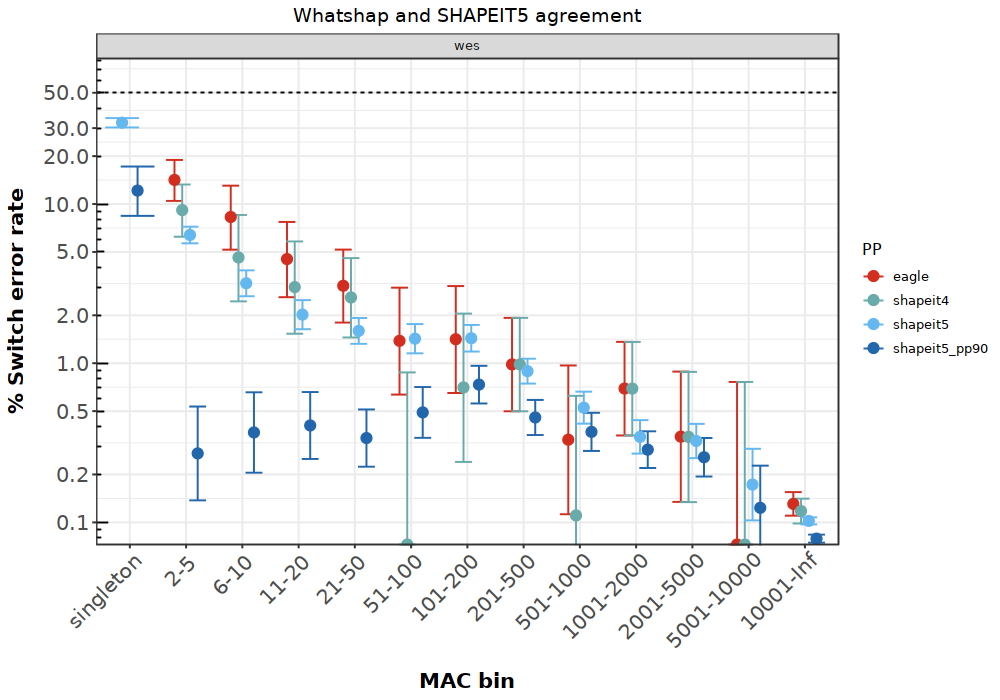

In [97]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 100)
pd <- position_dodge(width = 0.55)
p_compare <- ggplot(dat, aes(x=mac_bin, y=100*pointest, ymin=100*lower, ymax=100*upper, color = method, group = method)) +
    theme_bw() +
    theme(
        legend.position = "right",
        axis.text=element_text(size=15),
        axis.title=element_text(size=15,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 45, vjust = 0.96, hjust=0.95)
    ) +
    color_scale2 +
    coord_cartesian(ylim = c(0.1, 60)) +
    geom_hline(yintercept = 50, linetype = "dashed") +
    scale_y_continuous(trans = 'log10', breaks=c(0, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 30, 50)) +   
    annotation_logticks(sides='l')  +
    geom_errorbar(position = pd, width = 1.2) +
    geom_point(position = pd, size = 3) +
    xlab("MAC bin") +
    ylab("% Switch error rate") +
    labs(color = "Phasing Confidence")+
    ggtitle("Whatshap and SHAPEIT5 agreement") +
    facet_wrap(~wes_label)

p_compare

In [161]:
# subset
dat <- do.call(rbind, lst)
dat$wes_variant <- NULL
bool_remove <- dat$mac_bin == "singleton" & dat$method %in% c("eagle","shapeit4")
dat <- dat[!bool_remove,]
dat_eagle <- dat[dat$method == "eagle"]
dat_s4 <- dat[dat$method == "shapeit4",]
dat_s5 <- dat[dat$method == "shapeit5",]
dat_s5_pp90 <- dat[dat$method == "shapeit5_pp90",]
# remove method col
dat_eagle$method <- NULL
dat_s4$method <- NULL
dat_s5$method <- NULL
dat_s5_pp90$method <- NULL
# rename
colnames(dat_eagle)[2:6] <- paste0("eagle2_", colnames(dat_eagle)[2:6])
colnames(dat_s4)[2:6] <- paste0("shapeit4_", colnames(dat_s4)[2:6])
colnames(dat_s5)[2:6] <- paste0("shapeit5_", colnames(dat_s5)[2:6])
colnames(dat_s5_pp90)[2:6] <- paste0("shapeit5_pp90_", colnames(dat_s5_pp90)[2:6])

In [168]:
merge_all <- function(x, y) merge(x, y, all = TRUE)
combined <- Reduce(merge_all, list(dat_s5, dat_s5_pp90, dat_s4, dat_eagle))

In [172]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
combined[combined$wes_label == "array",]
combined[combined$wes_label == "wes",]

mac_bin,wes_label,shapeit5_switches,shapeit5_tested,shapeit5_pointest,shapeit5_lower,shapeit5_upper,shapeit5_pp90_switches,shapeit5_pp90_tested,shapeit5_pp90_pointest,shapeit5_pp90_lower,shapeit5_pp90_upper,shapeit4_switches,shapeit4_tested,shapeit4_pointest,shapeit4_lower,shapeit4_upper,eagle2_switches,eagle2_tested,eagle2_pointest,eagle2_lower,eagle2_upper
<fct>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
singleton,array,155,423,0.366430260,0.321906922,0.413357782,12,56,0.214285714,0.127059042,0.338194636,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2-5,array,36,428,0.084112150,0.061373572,0.114249813,7,309,0.022653722,0.011015868,0.046014485,3,26,0.115384615,0.0400324462,0.289759032,5,26,0.192307692,0.085070611,0.378762571
6-10,array,11,252,0.043650794,0.024546025,0.076459727,10,213,0.046948357,0.025698400,0.084250402,0,13,0.000000000,0.0000000000,0.228095372,0,13,0.000000000,0.000000000,0.228095372
11-20,array,17,283,0.060070671,0.037839940,0.094084709,9,253,0.035573123,0.018826009,0.066212672,1,13,0.076923077,0.0039456380,0.333139509,1,13,0.076923077,0.003945638,0.333139509
21-50,array,21,500,0.042000000,0.027632310,0.063351586,9,470,0.019148936,0.010106380,0.035988065,2,30,0.066666667,0.0184770238,0.213234584,1,30,0.033333333,0.001709776,0.166703910
51-100,array,9,349,0.025787966,0.013625288,0.048276334,7,333,0.021021021,0.010219086,0.042747846,0,11,0.000000000,0.0000000000,0.258832967,0,11,0.000000000,0.000000000,0.258832967
101-200,array,8,287,0.027874564,0.014190770,0.054030105,6,281,0.021352313,0.009821825,0.045793179,0,12,0.000000000,0.0000000000,0.242494007,0,12,0.000000000,0.000000000,0.242494007
201-500,array,13,486,0.026748971,0.015697700,0.045222947,11,474,0.023206751,0.013006747,0.041072819,1,28,0.035714286,0.0018319034,0.177121977,2,28,0.071428571,0.019812064,0.226453626
501-1000,array,12,835,0.014371257,0.008239771,0.024950599,12,835,0.014371257,0.008239771,0.024950599,1,44,0.022727273,0.0011657567,0.118077097,1,44,0.022727273,0.001165757,0.118077097


mac_bin,wes_label,shapeit5_switches,shapeit5_tested,shapeit5_pointest,shapeit5_lower,shapeit5_upper,shapeit5_pp90_switches,shapeit5_pp90_tested,shapeit5_pp90_pointest,shapeit5_pp90_lower,shapeit5_pp90_upper,shapeit4_switches,shapeit4_tested,shapeit4_pointest,shapeit4_lower,shapeit4_upper,eagle2_switches,eagle2_tested,eagle2_pointest,eagle2_lower,eagle2_upper
<fct>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
singleton,wes,569,1754,0.324401368,0.3028968753,0.346673342,26,214,0.1214953271,0.0842755044,0.1720644005,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2-5,wes,248,3880,0.063917526,0.0566439682,0.072053731,8,2949,0.0027127840,0.0013752544,0.0053441916,24,262,0.091603053,6.232983e-02,0.132679097,37,261,0.141762452,0.104629735,0.189287461
6-10,wes,106,3334,0.031793641,0.0263560616,0.038308921,11,2995,0.0036727880,0.0020520907,0.0065650566,9,195,0.046153846,2.446889e-02,0.085374693,16,193,0.082901554,0.051671409,0.130411467
11-20,wes,85,4209,0.020194821,0.0163621901,0.024902467,16,3937,0.0040640081,0.0025031468,0.0065917278,8,266,0.030075188,1.531679e-02,0.058213275,12,266,0.045112782,0.025991911,0.077185187
21-50,wes,108,6768,0.015957447,0.0132348443,0.019229214,22,6495,0.0033872209,0.0022380032,0.0051235334,11,425,0.025882353,1.451259e-02,0.045746184,13,424,0.030660377,0.018004106,0.051744765
51-100,wes,84,5890,0.014261460,0.0115345461,0.017621559,28,5704,0.0049088359,0.0033985308,0.0070855479,0,435,0.000000000,0.000000e+00,0.008753637,6,434,0.013824885,0.006351061,0.029829749
101-200,wes,102,7106,0.014354067,0.0118392238,0.017393701,51,6949,0.0073391855,0.0055867222,0.0096360410,3,426,0.007042254,2.397833e-03,0.020497722,6,424,0.014150943,0.006501214,0.030525256
201-500,wes,117,13123,0.008915644,0.0074448966,0.010673815,59,12934,0.0045616205,0.0035383049,0.0058791438,8,814,0.009828010,4.988248e-03,0.019272516,8,814,0.009828010,0.004988248,0.019272516
501-1000,wes,71,13506,0.005256923,0.0041701182,0.006625083,50,13499,0.0037039781,0.0028108657,0.0048794756,1,904,0.001106195,5.674037e-05,0.006239151,3,907,0.003307607,0.001125509,0.009679290


In [18]:
path <- "data/phased/validation/220713_ukb_eur_wes_union_calls_phasing_eagle_shapeit4.txt.gz"
d <- fread(path)
d$wes_label <- factor(d$wes_label)
d$chunk_current_w_label <- paste0("p",d$chunk_current)
d <- d[d$CHR %in% c("chr21","chr22")]
head(d, n = 2)

wes_variant,chunk_current,CHR,switches,tested,method,pointest,lower,upper,wes_label,chunk_current_w_label
<lgl>,<int>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
FALSE,1,chr21,256,147042,Eagle2,0.0017409992,0.0015405386,0.001967493,Genotyping Array,p1
TRUE,1,chr21,26,28489,Eagle2,0.0009126329,0.0006229079,0.001336934,Whole Exome Sequencing,p1


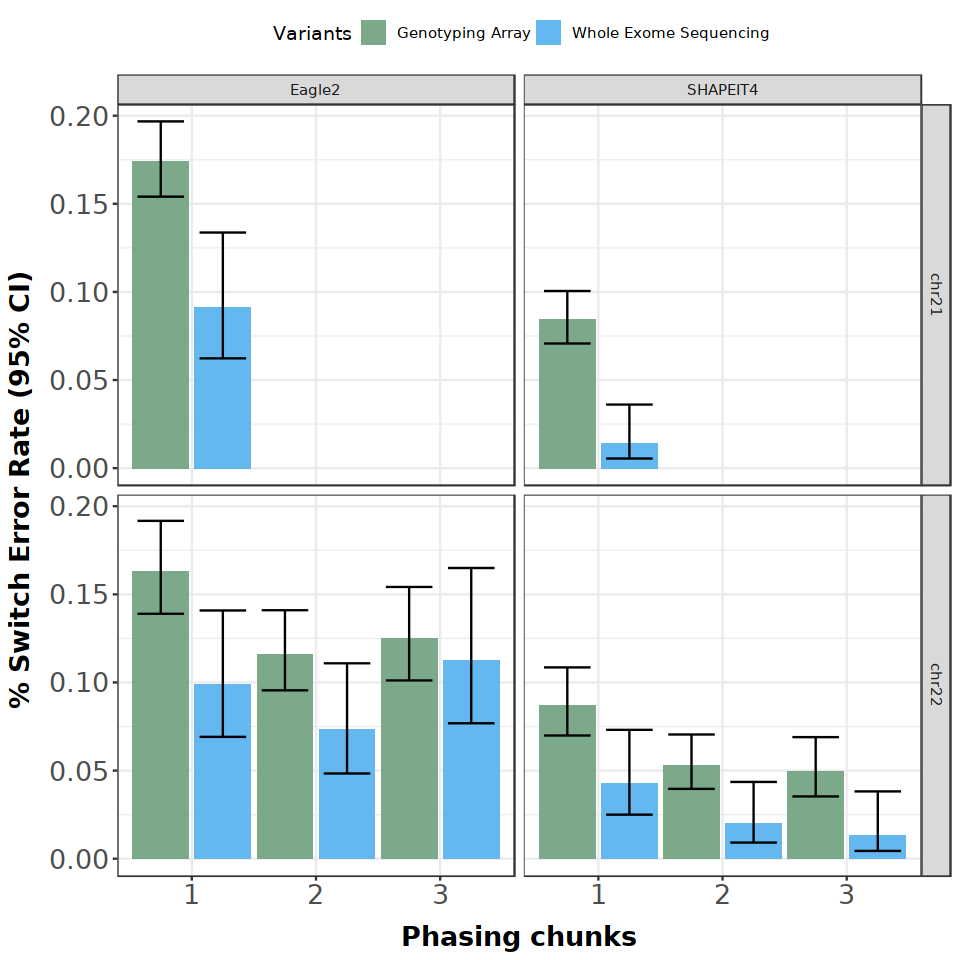

In [19]:
options(repr.plot.width=8, repr.plot.height=8)
pd <- position_dodge(1)
p1 <- ggplot(d,
   aes(
       x=factor(chunk_current),
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = wes_label,
   )) +
    theme_bw() +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_errorbar(stat='identity', position = pd,width = 0.75) +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Phasing chunks') +
    fill_scale +
    labs(fill = "Hello") +
    #scale_y_continuous(breaks=scales::pretty_breaks(n=4)) +
    #scale_x_continuous(breaks=scales::pretty_breaks(n=7)) +
    facet_grid(CHR~method) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
       # axis.text.x = element_text(angle = 0, vjust = 1, hjust=0)
    )
    p1

In [20]:
options(repr.matrix.max.rows=270, repr.matrix.max.cols=30)
d

wes_variant,chunk_current,CHR,switches,tested,method,pointest,lower,upper,wes_label,chunk_current_w_label
<lgl>,<int>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
FALSE,1,chr21,256,147042,Eagle2,0.0017409992,1.540539e-03,0.0019674930,Genotyping Array,p1
TRUE,1,chr21,26,28489,Eagle2,0.0009126329,6.229079e-04,0.0013369338,Whole Exome Sequencing,p1
FALSE,1,chr22,148,90669,Eagle2,0.0016323109,1.389820e-03,0.0019170299,Genotyping Array,p1
TRUE,1,chr22,30,30397,Eagle2,0.0009869395,6.914383e-04,0.0014085516,Whole Exome Sequencing,p1
FALSE,2,chr22,101,87028,Eagle2,0.0011605460,9.552974e-04,0.0014098308,Genotyping Array,p2
TRUE,2,chr22,22,30039,Eagle2,0.0007323812,4.837249e-04,0.0011087163,Whole Exome Sequencing,p2
FALSE,3,chr22,86,68860,Eagle2,0.0012489108,1.011487e-03,0.0015419791,Genotyping Array,p3
TRUE,3,chr22,26,23089,Eagle2,0.0011260774,7.686132e-04,0.0016495153,Whole Exome Sequencing,p3
FALSE,1,chr21,124,147049,SHAPEIT4,0.0008432563,7.073669e-04,0.0010052247,Genotyping Array,p1


# compare old WES naive phasing with WES+GENO union

In [77]:
fread_phased_sites <- function(file, ...){

    # get details about chunks
    bname <- basename(file)
    chunk_current <- as.numeric(gsub("of","",stringr::str_extract(bname, "[0-9]+of")))
    chunk_final <- as.numeric(gsub("of","",stringr::str_extract(bname, "of[0-9]+")))
    method <- unlist(strsplit(bname, split = '_'))[1]
    phasing_region_size <- as.numeric(gsub("_prs","",stringr::str_extract(bname, "_prs[0-9]+")))
    phasing_overlap_size <- as.numeric(gsub("_pro","",stringr::str_extract(bname, "_pro[0-9]+")))
    max_phasing_region_size <- as.numeric(gsub("_mprs","",stringr::str_extract(bname, "_mprs[0-9]+")))

    # append to data.table
    d <- fread(file, ...)
    d$locus <- paste0(d$CHR,":",d$POS)
    d$chunk_current <- chunk_current
    d$chunk_final <- chunk_final
    d$method <- method
    d$phasing_region_size <- phasing_region_size
    d$phasing_overlap_size <- phasing_overlap_size
    d$max_phasing_region_size <- max_phasing_region_size
    return(d)

}

In [78]:
files_chr22 <- list.files("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phased/wes/chunks/final/ukb_eur_wes_200k_chr22-18xshort.qe", pattern = '.txt', full.names = TRUE)
files_chr22 <- files_chr22[!grepl('shapeit4_prs150000_pro75000_mprs200000.1of1.txt', files_chr22)]

In [79]:
files_chr21 <- list.files("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phased/wes/chunks/final/ukb_eur_wes_200k_chr21-18xshort.qe/", pattern = '.txt', full.names = TRUE)
files_chr21 <- files_chr21[1]

In [80]:
files <- c(files_chr21, files_chr22)

In [87]:
chroms <- c("chr21","chr22")
lst <- lapply(chroms, function(chr){

    # subset by chromosome (if we read in all at the same time it takes too long)
    files_chr <- files[grepl(paste0(chr,"-"), files)]
    d <- data.table(do.call(rbind, lapply(files_chr, fread_phased_sites)))
    d$wes_variant <- TRUE

    # get counts
    counts <- aggregate(switches ~ wes_variant + chunk_current + CHR, data = d, FUN = sum)
    tested <- aggregate(switches ~ wes_variant + chunk_current + CHR, data = d, FUN = length)
    counts <- data.table(counts, tested = tested$switches)
    return(counts)
})


In [88]:
# combine counts and add conf int
counts <- do.call(rbind, lst)
counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$switches[i], counts$tested[i])))
colnames(counts_ci) <- tolower(colnames(counts_ci))
counts <- cbind(counts, counts_ci)

In [90]:
counts

wes_variant,chunk_current,CHR,switches,tested,pointest,lower,upper
<lgl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
TRUE,1,chr21,1173,22094,0.053091337,0.05021177,0.056126283
TRUE,1,chr22,696,24130,0.028843763,0.02680586,0.031031659
TRUE,2,chr22,325,25379,0.012805863,0.01149444,0.014264755
TRUE,3,chr22,126,16905,0.007453416,0.00626408,0.008866552
